# Exemplo: Conjuntos de dados desbalanceados
------------------------------

Este exemplo mostra como o ExperionML pode ajudar a lidar com conjuntos de dados desbalanceados. Vamos avaliar o desempenho de três modelos Random Forest diferentes: um treinado diretamente no conjunto desbalanceado, um treinado em um conjunto com oversampling e outro treinado em um conjunto com undersampling.

## Carregar os dados

In [1]:
# Import packages
from experionml import ExperionMLClassifier
from sklearn.datasets import make_classification

In [2]:
# Crie um conjunto de dados desbalanceado fictício
X, y = make_classification(
    n_samples=5000,
    n_features=30,
    n_informative=20,
    weights=(0.95,),
    random_state=1,
)

## Executar o pipeline

In [3]:
# Initialize experionml
experionml = ExperionMLClassifier(X, y, test_size=0.2, verbose=2, random_state=1)

<< ================== ExperionML ================== >>

Configuração ==================== >>
Tarefa do algoritmo: Binary classification.

Estatísticas do conjunto de dados ==================== >>
Formato: (5000, 31)
Tamanho do conjunto de train: 4000
Tamanho do conjunto de test: 1000
-------------------------------------
Memória: 1.24 MB
Escalonado: False
Valores atípicos: 570 (0.5%)



In [4]:
# Vamos observar os dados. Note que, como a entrada não era
# um dataframe, o experionml atribuiu nomes padrão às colunas.
experionml.head()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x21,x22,x23,x24,x25,x26,x27,x28,x29,target
0,-0.535760,-2.426045,1.256836,0.374501,-3.241958,-1.239468,-0.208750,-6.015995,3.698669,0.112512,...,0.044302,-1.935727,10.870353,0.286755,-2.416507,0.556990,-1.522635,3.719201,1.449135,0
1,-3.311935,-3.149920,-0.801252,-2.644414,-0.704889,-3.312256,0.714515,2.992345,5.056910,3.036775,...,2.224359,0.451273,-1.822108,-1.435801,0.036132,-1.364583,1.215663,5.232161,1.408798,0
2,3.821199,1.328129,-1.000720,-13.151697,0.254253,1.263636,-1.088451,4.924264,-1.225646,-6.974824,...,3.541222,1.686667,-13.763703,-1.321256,1.677687,0.774966,-5.067689,4.663386,-1.714186,0
3,5.931126,3.338830,0.545906,2.296355,-3.941088,3.527252,-0.158770,3.138381,-0.927460,-1.642079,...,-3.634442,7.853176,-8.457598,0.000490,-2.612756,-1.138206,0.497150,4.351289,-0.321748,0
4,-2.829472,-1.227185,-0.751892,3.056106,-1.988920,-2.219184,-0.075882,5.790102,-2.786671,2.023458,...,4.057954,1.178564,-15.028187,1.627140,-1.093587,-0.422655,1.777011,6.660638,-2.553723,0


In [5]:
# Vamos começar reduzindo o número de variáveis
experionml.feature_selection("rfe", solver="rf", n_features=12)

Fitting FeatureSelector...


Performing feature selection ...
 --> rfe selected 12 features from the dataset.
   --> Dropping feature x1 (rank 8).
   --> Dropping feature x2 (rank 11).
   --> Dropping feature x4 (rank 3).
   --> Dropping feature x6 (rank 16).
   --> Dropping feature x7 (rank 14).
   --> Dropping feature x10 (rank 19).
   --> Dropping feature x12 (rank 13).
   --> Dropping feature x13 (rank 12).
   --> Dropping feature x14 (rank 9).
   --> Dropping feature x16 (rank 10).
   --> Dropping feature x18 (rank 17).
   --> Dropping feature x19 (rank 2).
   --> Dropping feature x20 (rank 4).
   --> Dropping feature x22 (rank 7).
   --> Dropping feature x23 (rank 5).
   --> Dropping feature x24 (rank 18).
   --> Dropping feature x25 (rank 6).
   --> Dropping feature x26 (rank 15).


In [6]:
# Ajuste um modelo diretamente nos dados desbalanceados
experionml.run("RF", metric="ba")


Training ========================= >>
Models: RF
Metric: ba


Results for RandomForest:
Fit ---------------------------------------------


Train evaluation --> ba: 1.0
Test evaluation --> ba: 0.5556
Time elapsed: 1.348s
-------------------------------------------------
Time: 1.348s


Resultados finais ==================== >>
Tempo total: 1.351s
-------------------------------------
RandomForest --> ba: 0.5556 ~


In [7]:
# O transformador e os modelos foram adicionados ao branch
experionml.branch

Branch(main)

## Oversampling

In [8]:
# Create a new branch for oversampling
experionml.branch = "oversample"

Nova branch criada com sucesso: oversample.


In [9]:
# Faça oversampling da classe minoritária
experionml.balance(strategy="smote")

Oversampling with SMOTE...
 --> Adding 3570 samples to class 1.


In [10]:
experionml.classes  # Verifique o conjunto de treino balanceado!

,dataset,train,test
0,4731,3785,946
1,3839,3785,54


In [11]:
# Treine outro modelo no novo branch. Adicione uma tag após 
# a sigla do modelo para distingui-lo do primeiro modelo
experionml.run("rf_os")  # os for oversample


Training ========================= >>
Models: RF_os
Metric: ba


Results for RandomForest:
Fit ---------------------------------------------


Train evaluation --> ba: 1.0
Test evaluation --> ba: 0.7672
Time elapsed: 2.794s
-------------------------------------------------
Time: 2.794s


Resultados finais ==================== >>
Tempo total: 2.797s
-------------------------------------
RandomForest --> ba: 0.7672 ~


## Undersampling

In [12]:
# Crie o branch de undersampling
# Faça split a partir de master para não adotar o transformador de oversampling
experionml.branch = "undersample_from_main"

Nova branch criada com sucesso: undersample.


In [13]:
experionml.classes  # Neste branch, os dados ainda estão desbalanceados

,dataset,train,test
0,4731,3785,946
1,269,215,54


In [14]:
# Faça undersampling da classe majoritária
experionml.balance(strategy="NearMiss")

Undersampling with NearMiss...
 --> Removing 3570 samples from class 0.


In [15]:
experionml.run("rf_us")


Training ========================= >>
Models: RF_us
Metric: ba


Results for RandomForest:
Fit ---------------------------------------------


Train evaluation --> ba: 1.0
Test evaluation --> ba: 0.6706
Time elapsed: 0.352s
-------------------------------------------------
Time: 0.352s


Resultados finais ==================== >>
Tempo total: 0.357s
-------------------------------------
RandomForest --> ba: 0.6706 ~


In [16]:
# Verifique se o branch contém apenas os transformadores desejados 
experionml.branch

Branch(undersample)

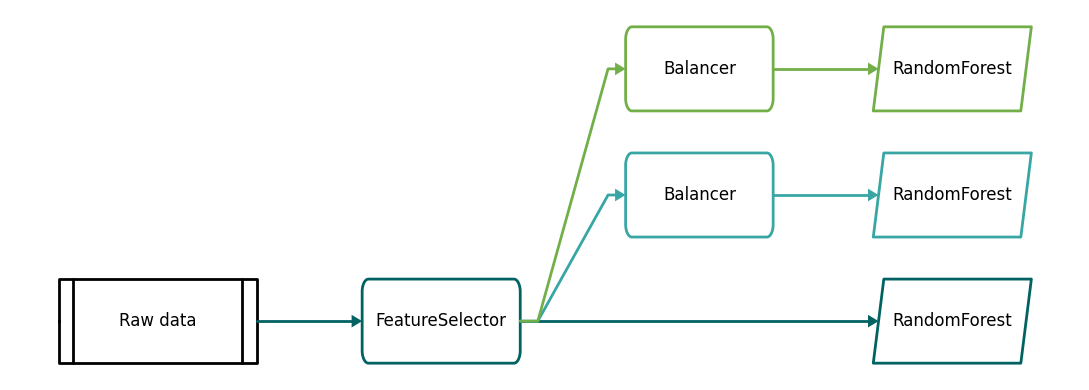

In [17]:
# Visualize o pipeline completo
experionml.plot_pipeline()

## Analisar os resultados

In [18]:
experionml.evaluate()

,accuracy,ap,ba,f1,jaccard,mcc,precision,recall,auc
RF,0.952000,0.656200,0.555600,0.200000,0.111100,0.325200,1.000000,0.111100,0.910700
RF_os,0.956000,0.621500,0.767200,0.576900,0.405400,0.554200,0.600000,0.555600,0.925100
RF_us,0.509000,0.368700,0.670600,0.157800,0.085700,0.154500,0.087000,0.851900,0.825800


In [19]:
experionml.plot_prc()

In [20]:
experionml.plot_roc()